In [16]:
#imports 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder

In [2]:
df=pd.read_csv("MBA.csv")
print(df.index)
print("All columns are")
ai=0
for i in df:
    print(ai,i)
    ai+=1

RangeIndex(start=0, stop=6194, step=1)
All columns are
0 application_id
1 gender
2 international
3 gpa
4 major
5 race
6 gmat
7 work_exp
8 work_industry
9 admission


In [3]:
df.sample(n=10)

,application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission
3118,3119,Male,False,3.21,Business,Black,620.0,4.0,Consulting,NaN
6193,6194,Male,False,3.23,STEM,Hispanic,650.0,4.0,Consulting,NaN
957,958,Male,False,3.17,STEM,Black,580.0,5.0,PE/VC,NaN
4485,4486,Male,True,3.36,Humanities,NaN,710.0,2.0,Other,Admit
765,766,Male,False,3.08,STEM,Black,570.0,4.0,Nonprofit/Gov,NaN
223,224,Female,False,3.19,Business,Asian,630.0,5.0,Investment Banking,Admit
884,885,Male,False,3.23,Business,Hispanic,630.0,3.0,Financial Services,NaN
5378,5379,Male,False,3.30,STEM,Black,590.0,6.0,Technology,NaN
1190,1191,Male,True,3.12,Humanities,NaN,620.0,7.0,Consulting,NaN
6192,6193,Male,True,3.36,Business,NaN,590.0,5.0,Other,NaN


In [5]:
# Filling missing values

# Filling missing race with unknown
df["race"] = df["race"].fillna("Unknown")



# Filling missing admission value with Rejected
df["admission"] = df["admission"].fillna("Rejected")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6194 entries, 0 to 6193
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   application_id  6194 non-null   int64  
 1   gender          6194 non-null   object 
 2   international   6194 non-null   bool   
 3   gpa             6194 non-null   float64
 4   major           6194 non-null   object 
 5   race            6194 non-null   object 
 6   gmat            6194 non-null   float64
 7   work_exp        6194 non-null   float64
 8   work_industry   6194 non-null   object 
 9   admission       6194 non-null   object 
dtypes: bool(1), float64(3), int64(1), object(5)
memory usage: 441.7+ KB


In [7]:
# Dropping application_id
df = df.drop(['application_id'],axis=1)

<Axes: >

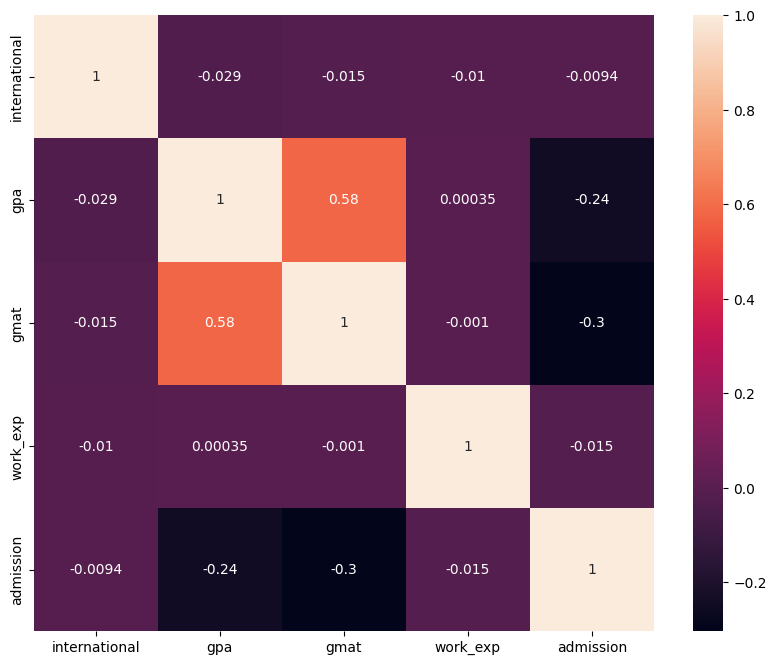

In [15]:
adf = df

le = LabelEncoder()
adf['admission'] = le.fit_transform(df['admission'])

plt.figure(figsize=(10,8))
sns.heatmap(adf.corr(numeric_only=True),annot=True)

In [32]:
print('''The Heatmap may not give the best relationship between the features.
As our feature are mostly categorial and the admission is also categorial
So the best test will be Pearson's Chi-Square Test of Independence
''')

The Heatmap may not give the best relationship between the features.
As our feature are numerical and the Defaulted is categorial
Defaulted means whether the person was able to make payment on time or not
So the best test will be ANOVA F-Test


In [33]:
# Isolating input and target
X = df.drop(columns=["Defaulted"])
y = df["Defaulted"]

In [39]:
# Function to print contigency table

def chi_square_test(column_name):

    contingency_table = pd.crosstab(df[column_name], df["admission"])

    chi2, p, dof, expected = chi2_contingency(contingency_table)

    print("Contingency Table:")
    print(contingency_table)
    print("\nChi-Square Statistic:", chi2)
    print("Degrees of Freedom:", dof)
    print("P-value:", p)

    if p < 0.05:
        print("\nResult: Significant association between", column_name, "and admission.")
    else:
        print("\nResult: No significant association between", column_name, "and admission.")

    return p

In [41]:
a = []
for i in df.columns :
    b = chi_square_test(i)
    if b < 0.05:
        a.append(i)
    print('\n')
    print()
print('The Significant columns are',a)

Contingency Table:
admission    0     1   2
gender                  
Female     450  1751  50
Male       450  3443  50

Chi-Square Statistic: 96.16293493778068
Degrees of Freedom: 2
P-value: 1.3136630861940511e-21

Result: Significant association between gender and admission.



Contingency Table:
admission        0     1   2
international               
False          622  3660  70
True           278  1534  30

Chi-Square Statistic: 0.6771777625905686
Degrees of Freedom: 2
P-value: 0.7127754241704354

Result: No significant association between international and admission.



Contingency Table:
admission  0  1  2
gpa               
2.65       0  1  0
2.72       0  1  0
2.73       0  1  0
2.78       0  5  0
2.79       0  1  0
...       .. .. ..
3.71       0  2  0
3.73       1  0  0
3.74       1  1  0
3.76       0  2  0
3.77       0  1  0

[101 rows x 3 columns]

Chi-Square Statistic: 746.7372813875913
Degrees of Freedom: 200
P-value: 4.497178828232643e-64

Result: Significant associatio